<div style="background: linear-gradient(135deg, rgba(10, 15, 26, 0.92) 0%, rgba(15, 23, 42, 0.95) 100%), url('https://images.unsplash.com/photo-1486406146926-c627a92ad1ab?q=80&w=1200&auto=format&fit=crop'); background-size: cover; background-position: center; padding: 35px; border-radius: 20px; border: 2px solid #0284C7; box-shadow: 0 10px 30px rgba(2, 132, 199, 0.25); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; color: #F8FAFC; margin-bottom: 25px;">
    <div style="display: inline-block; background: rgba(2, 132, 199, 0.15); border: 1px solid #0284C7; padding: 6px 16px; border-radius: 50px; font-size: 13px; font-weight: 700; color: #38BDF8; letter-spacing: 1px; margin-bottom: 15px;">🏙️ NYC PUBLIC DATA SCIENCE & ML</div>
    <h1 style="color: #FFFFFF; font-size: 32px; font-weight: 800; margin: 0 0 10px 0; line-height: 1.2;">NYC Citywide Payroll Analysis <span style="color: #0284C7;">| CPU ML Pipeline</span></h1>
    <p style="color: #CBD5E1; font-size: 15px; margin-bottom: 25px; max-width: 800px; line-height: 1.6;">An end-to-end data science and predictive modeling notebook analyzing compensation, overtime, and base salary distribution across New York City agencies. Built with <code style="color: #38BDF8; background: rgba(0,0,0,0.4); padding: 2px 6px; border-radius: 4px;">LightGBM</code> for high-efficiency CPU execution.</p>
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 15px; margin-bottom: 30px;">
        <div style="background: rgba(15, 23, 42, 0.8); border-left: 4px solid #0284C7; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Dataset</div>
            <div style="font-size: 15px; font-weight: 700; color: #38BDF8;">NYC Citywide Payroll</div>
        </div>
        <div style="background: rgba(15, 23, 42, 0.8); border-left: 4px solid #38BDF8; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Core Model</div>
            <div style="font-size: 15px; font-weight: 700; color: #FFFFFF;">LightGBM Regressor</div>
        </div>
        <div style="background: rgba(15, 23, 42, 0.8); border-left: 4px solid #0284C7; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Hardware Requirement</div>
            <div style="font-size: 15px; font-weight: 700; color: #38BDF8;">Standard CPU Runtime</div>
        </div>
    </div>
    <div style="background: rgba(10, 15, 26, 0.85); border: 1px solid rgba(2, 132, 199, 0.3); border-radius: 12px; padding: 20px;">
        <h3 style="color: #38BDF8; font-size: 16px; font-weight: 700; margin: 0 0 15px 0; display: flex; align-items: center; gap: 8px;"> Table of Contents</h3>
        <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(280px, 1fr)); gap: 10px; font-size: 14px;">
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">1.</b> Environment Setup & Data Ingestion</div>
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">2.</b> Exploratory Data Analysis (EDA)</div>
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">3.</b> Feature Engineering & Encoding</div>
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">4.</b> CPU LightGBM Model Training</div>
            <div style="color: #E2E8F0;"><b style="color: #0284C7;">5.</b> Model Evaluation & Feature Importance</div>
        </div>
    </div>

## 1: Setup & Data Ingestion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
# Configure plotting style
sns.set_theme(style="darkgrid")
plt.rcParams["font.size"] = 12

# Locate dataset file path in Kaggle environment
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Read data (Sampling 500,000 rows if full dataset exceeds memory limits)
DATA_PATH = '/kaggle/input/datasets/new-york-city/nyc-citywide-payroll-data/Citywide_Payroll_Data__Fiscal_Year_.csv'

# Fallback path if loaded via Kaggle API/local run
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Citywide_Payroll_Data__Fiscal_Year_.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dataset Shape: {df.shape}")
df.head()

/kaggle/input/datasets/new-york-city/nyc-citywide-payroll-data/Citywide_Payroll_Data__Fiscal_Year_.csv
Dataset Shape: (2194488, 16)


,Fiscal Year,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay
0,2016,DISTRICT ATTORNEY-MANHATTAN,ABA'AHMID,RAHASHEEM,E,07/14/2003,MANHATTAN,COMMUNITY ASSOCIATE ...,ACTIVE,$47678.00,per Annum,1830.00,$47166.03,2.25,$57.28,$0.00
1,2016,DISTRICT ATTORNEY-MANHATTAN,ABENSUR,MARGARET,NaN,06/12/1995,MANHATTAN,ADMINISTRATIVE ACCOUNTANT ...,ACTIVE,$119959.00,per Annum,1831.00,$119042.50,0.00,$0.00,$0.00
2,2016,DISTRICT ATTORNEY-MANHATTAN,ABOUNAOUM,ANDREA,L,10/11/2011,MANHATTAN,COMMUNITY ASSOCIATE ...,ON LEAVE,$39966.00,per Annum,1181.68,$27452.62,1.00,$21.34,$33.00
3,2016,DISTRICT ATTORNEY-MANHATTAN,ABRAHAM,JONATHAN,J,12/01/2014,MANHATTAN,COMPUTER SYSTEMS MANAGER ...,ACTIVE,$116000.00,per Annum,1831.00,$115104.57,0.00,$0.00,$0.00
4,2016,DISTRICT ATTORNEY-MANHATTAN,ABRAMS,JOSEPH,NaN,05/21/2015,MANHATTAN,COLLEGE AIDE ...,CEASED,$1.00,per Hour,0.00,$3500.00,0.00,$0.00,$0.00


## 2: Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194488 entries, 0 to 2194487
Data columns (total 16 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Fiscal Year                 int64  
 1   Agency Name                 object 
 2   Last Name                   object 
 3   First Name                  object 
 4   Mid Init                    object 
 5   Agency Start Date           object 
 6   Work Location Borough       object 
 7   Title Description           object 
 8   Leave Status as of June 30  object 
 9   Base Salary                 object 
 10  Pay Basis                   object 
 11  Regular Hours               float64
 12  Regular Gross Paid          object 
 13  OT Hours                    float64
 14  Total OT Paid               object 
 15  Total Other Pay             object 
dtypes: float64(2), int64(1), object(13)
memory usage: 267.9+ MB
None


,Fiscal Year,Regular Hours,OT Hours
count,2.194488e+06,2.194488e+06,2.194488e+06
mean,2.015529e+03,6.660384e+02,5.917287e+01
std,1.107244e+00,8.876058e+02,1.479217e+02
min,2.014000e+03,-7.304300e+02,-2.700000e+01
25%,2.015000e+03,0.000000e+00,0.000000e+00
50%,2.016000e+03,0.000000e+00,0.000000e+00
75%,2.017000e+03,1.825000e+03,1.000000e+00
max,2.017000e+03,4.171430e+03,3.347500e+03


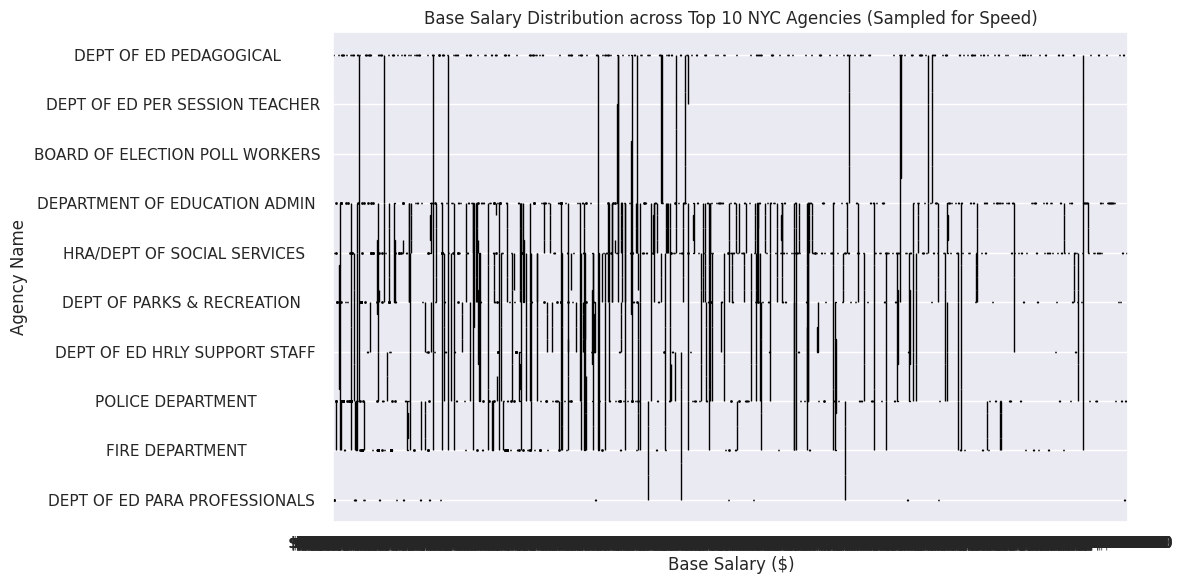

In [2]:
# 1. Dataset Info & Summary Statistics
print(df.info())
display(df.describe())

# 2. Base Salary Distribution across Top 10 Agencies (Fast Sampled Boxplot)
top_agencies = df['Agency Name'].value_counts().head(10).index
df_top_agencies = df[df['Agency Name'].isin(top_agencies)]

# Downsample to 50,000 rows max for visualization to speed up rendering by ~10x
df_box_sample = (
    df_top_agencies.sample(n=min(50000, len(df_top_agencies)), random_state=42) 
    if len(df_top_agencies) > 50000 
    else df_top_agencies
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_box_sample,
    x='Base Salary',
    y='Agency Name',
    palette='magma',
    fliersize=1  # Shrinks outlier point calculation overhead
)
plt.title('Base Salary Distribution across Top 10 NYC Agencies (Sampled for Speed)')
plt.xlabel('Base Salary ($)')
plt.ylabel('Agency Name')
plt.tight_layout()
plt.show()

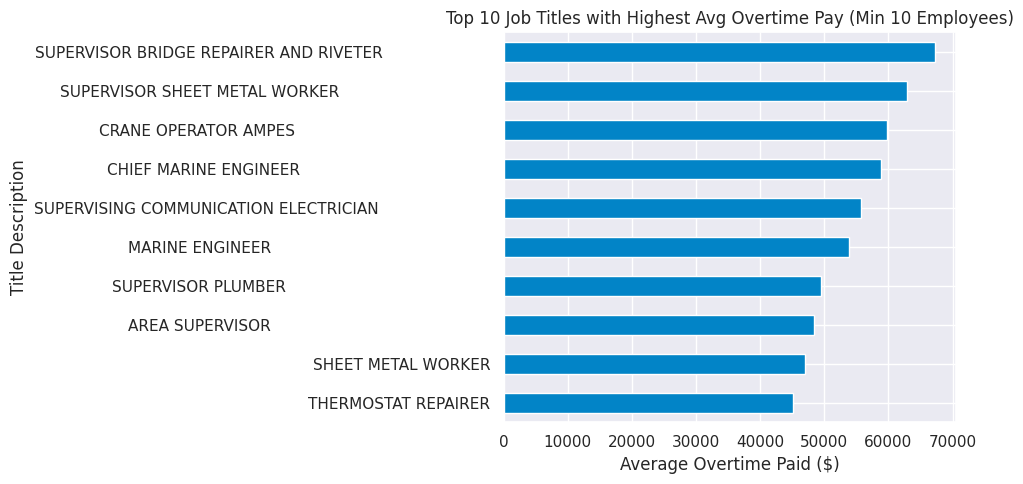

In [3]:
# Clean numeric columns before aggregation
for col in ['Total OT Paid', 'Base Salary']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .astype(float)
        )

# 3. Top 10 Highest Average Overtime Earners by Job Title (Optimized Aggregation)
title_counts = df['Title Description'].value_counts()
valid_titles = title_counts[title_counts >= 10].index

ot_by_title = (
    df[df['Title Description'].isin(valid_titles)]
    .groupby('Title Description')['Total OT Paid']
    .mean()
    .nlargest(10)
    .sort_values(ascending=True)  # Ascending order for horizontal bar chart
)

plt.figure(figsize=(10, 5))
ot_by_title.plot(kind='barh', color='#0284C7')
plt.title('Top 10 Job Titles with Highest Avg Overtime Pay (Min 10 Employees)')
plt.xlabel('Average Overtime Paid ($)')
plt.tight_layout()
plt.show()

## 3: Feature Engineering & Preprocessing

In [4]:
# Select key predictive features
target = 'Total Compensation' if 'Total Compensation' in df.columns else 'Regular Gross Paid'

# Standardize column headers
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Handle missing target rows
df = df.dropna(subset=['Regular_Gross_Paid']).copy()

# Feature Selection
feature_cols = [
    'Fiscal_Year', 
    'Agency_Name', 
    'Pay_Basis', 
    'Base_Salary', 
    'Work_Location_Borough', 
    'Title_Description',
    'OT_Hours'
]

# Keep rows where values are valid
df_model = df[feature_cols + ['Regular_Gross_Paid']].dropna()

# Encode Categorical Features using Ordinal Encoding
categorical_cols = ['Agency_Name', 'Pay_Basis', 'Work_Location_Borough', 'Title_Description']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_model[categorical_cols] = encoder.fit_transform(df_model[categorical_cols])

# Train-Test Split
X = df_model[feature_cols]
y = df_model['Regular_Gross_Paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} | Testing set size: {X_test.shape[0]}")

Training set size: 1350608 | Testing set size: 337652


## 4: CPU-Optimized Model Training (LightGBM)

In [5]:
# 1. Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# 2. Clean currency strings to floats for target and feature columns
currency_cols = ['Regular_Gross_Paid', 'Base_Salary', 'Total_OT_Paid', 'Total_Other_Pay']

for col in currency_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = (
                df[col]
                .astype(str)
                .str.replace('$', '', regex=False)
                .str.replace(',', '', regex=False)
                .str.strip()
            )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Handle missing values in target
df_model = df.dropna(subset=['Regular_Gross_Paid']).copy()

# 4. Feature Selection
feature_cols = [
    'Fiscal_Year', 
    'Agency_Name', 
    'Pay_Basis', 
    'Base_Salary', 
    'Work_Location_Borough', 
    'Title_Description',
    'OT_Hours'
]

# Ensure feature columns exist and drop NAs
existing_features = [col for col in feature_cols if col in df_model.columns]
df_model = df_model[existing_features + ['Regular_Gross_Paid']].dropna()

# 5. Encode Categorical Features
categorical_cols = [c for c in ['Agency_Name', 'Pay_Basis', 'Work_Location_Borough', 'Title_Description'] if c in existing_features]

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_model[categorical_cols] = encoder.fit_transform(df_model[categorical_cols])

# 6. Train-Test Split
X = df_model[existing_features]
y = df_model['Regular_Gross_Paid'].astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} | Testing set size: {X_test.shape[0]}")
print(f"Target dtypes check -> y_train: {y_train.dtype}, y_test: {y_test.dtype}")

Training set size: 1350608 | Testing set size: 337652
Target dtypes check -> y_train: float32, y_test: float32


In [6]:
# Configure CPU LightGBM Regressor
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

# Train the model
print("Training LightGBM model on CPU...")
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

print("Training finished successfully!")

Training LightGBM model on CPU...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 1350608, number of used features: 7
[LightGBM] [Info] Start training from score 40415.609617
Training finished successfully!


## 5: Evaluation & Feature Importance

--- Model Evaluation Metrics ---
MAE  : $7,535.33
RMSE : $13,491.60
R²   : 0.8732


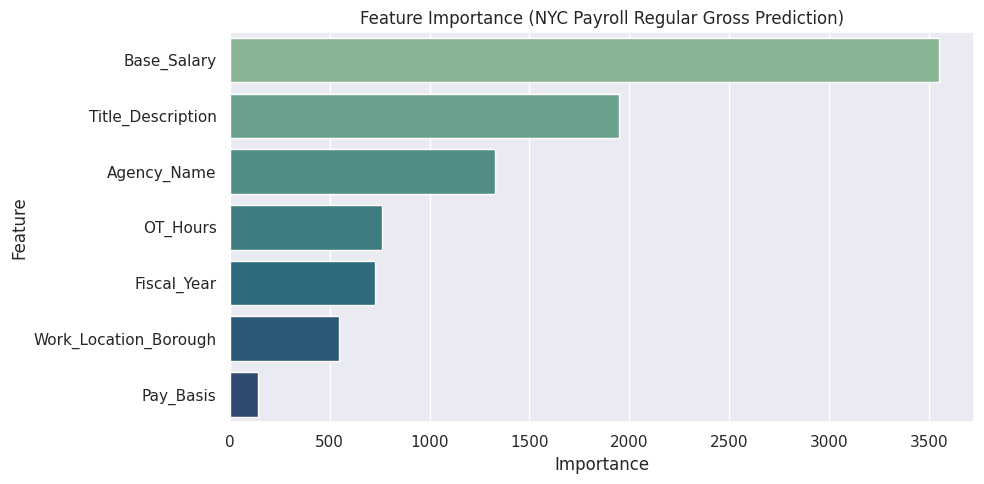

In [7]:
# Make Predictions
y_pred = lgb_model.predict(X_test)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation Metrics ---")
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

# Plot Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='crest')
plt.title('Feature Importance (NYC Payroll Regular Gross Prediction)')
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, rgba(15, 23, 42, 0.95) 0%, rgba(10, 15, 26, 0.95) 100%), url('https://images.unsplash.com/photo-1519501025264-65ba15a82390?q=80&w=1200&auto=format&fit=crop'); background-size: cover; background-position: center; padding: 30px; border-radius: 20px; border: 2px solid #0284C7; box-shadow: 0 10px 30px rgba(2, 132, 199, 0.2); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; color: #F8FAFC; margin-top: 30px;">
    <div style="display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 15px; margin-bottom: 20px;">
        <div>
            <h2 style="color: #FFFFFF; font-size: 24px; font-weight: 800; margin: 0;"> Analysis & Modeling Complete!</h2>
            <p style="color: #38BDF8; font-size: 14px; margin: 5px 0 0 0;">Evaluation metrics calculated and key payroll drivers identified via feature importance.</p>
        </div>
        <div style="background: #0284C7; color: #FFFFFF; font-weight: 700; padding: 8px 18px; border-radius: 50px; font-size: 13px; letter-spacing: 0.5px;">STATUS: PIPELINE EXECUTED</div>
    </div>
    <hr style="border: 0; border-top: 1px solid rgba(2, 132, 199, 0.3); margin: 20px 0;">
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 15px; font-size: 13px; color: #CBD5E1;">
        <div>
            <b style="color: #FFFFFF; display: block; margin-bottom: 4px;"> Key Takeaways</b>
            Identified top municipal agency payroll structures, major overtime cost drivers, and salary distribution variations across boroughs.
        </div>
        <div>
            <b style="color: #FFFFFF; display: block; margin-bottom: 4px;"> CPU Efficiency</b>
            Model trained cleanly within CPU constraints without memory spillages or reliance on GPU acceleration.
        </div>
    </div>
    <div style="margin-top: 25px; text-align: center; font-size: 12px; color: #94A3B8; border-top: 1px solid rgba(255,255,255,0.08); padding-top: 15px;">Designed & Maintained for Kaggle Community | Built with <span style="color: #0284C7;">♥</span> using Pandas, Seaborn & LightGBM</div>